In [1]:
!pip install faiss-cpu timm albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 86.6 MB/s eta 0:00:00


In [2]:
import json

with open('/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/train_results/annotations.json', 'r') as f:
    annotations = json.load(f)

annotations_dict = {}
for annot in annotations:
    annotations_dict[f"{annot['image_path']}_{annot['image_id']}"] = annot

In [5]:
len(annotations_dict)

37801

In [7]:
list(annotations_dict.keys())[:2]

['/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/리조트/995453.jpg_1',
 '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/페미닌/868254.jpg_0']

In [8]:
annotations_dict['/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/리조트/995453.jpg_1']

{'image_path': '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/리조트/995453.jpg',
 'image_id': 1,
 'box': [297, 417, 481, 706],
 'detail_category': '티셔츠',
 'color': '핑크',
 'fit': '노멀',
 'length': '노멀'}

In [9]:
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
import pickle
import json

vecto_dir = '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/vectors'

normalizer = Normalizer(norm='l2')
pca_path = os.path.join(vecto_dir, 'pca_model.pkl')
with open(pca_path, 'rb') as f:
    pca = pickle.load(f)

feature_path = os.path.join(vecto_dir, 'feature_map.json')
with open(feature_path, 'r') as f:
    feature_map = json.load(f)

image_path_id_list = []
feature_list = []
for key, value in feature_map.items():
    image_path_id_list.append(key)
    feature_list.append(value)

norm_feature_list = normalizer.fit_transform(feature_list)

com_feature_list = pca.transform(norm_feature_list)

In [10]:
com_feature_list[0]

array([-3.43529395e-01, -4.75757542e-02, -2.60033233e-02, -1.64515535e-01,
       -2.00302081e-01, -7.90675802e-03,  1.70538787e-01, -1.63789155e-01,
       -4.08800244e-02, -3.40656161e-01,  1.53394182e-01, -1.27233647e-01,
       -1.65045431e-01, -5.36765546e-03, -1.17283967e-01, -8.11498077e-02,
       -3.09853821e-02, -3.91987374e-02,  8.23520478e-02,  8.03887906e-02,
        5.31040839e-02,  5.16019764e-03, -5.14647587e-02, -1.16537643e-02,
       -2.65040819e-02,  7.53411408e-02,  2.82433891e-02,  1.18997806e-01,
       -7.58613730e-02,  2.41957521e-02,  7.67816295e-02, -9.76832652e-02,
        2.45762063e-02,  3.08306177e-02, -1.43497363e-02,  2.26681804e-02,
        2.51046042e-02,  2.57193950e-02,  2.72189914e-02,  1.10123347e-02,
        1.22815089e-01,  2.17044952e-02,  1.88911139e-03, -5.16183009e-02,
       -1.02510058e-01, -6.42530037e-02, -4.46625196e-02,  5.97901815e-02,
       -3.38474938e-02, -2.59527802e-02,  2.88900750e-02, -3.29489864e-02,
       -5.92240184e-02,  

In [11]:
com_feature_list[0].shape

(128,)

In [13]:
image_path_id_list[0]

'/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/스트리트/209374.jpg_1'

In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def draw_image(images, distances):
    fig, axs = plt.subplots(2, 4, figsize=(12, 6))

    for i, ax in enumerate(axs.flat):
        if i >= len(images):
            break
        ax.imshow(images[i])
        ax.set_title(distances[i])

    plt.tight_layout()
    plt.show()

In [17]:
com_feature_list[0].shape[0]

128

In [18]:
import os
import faiss
import random

index_dir = 'index'
os.makedirs(index_dir, exist_ok=True)

with open(os.path.join(index_dir, 'image_path_id_list.json'), 'w') as f:
    json.dump(image_path_id_list, f, ensure_ascii=False, indent='\t')

d = com_feature_list[0].shape[0]

index = faiss.IndexFlatL2(d)

index.add(com_feature_list)

faiss.write_index(index, os.path.join(index_dir, 'flat_index.index'))

k = 8
random_idx = random.randint(0, len(com_feature_list))
query_vector = com_feature_list[random_idx].reshape(1, -1)

distances, indices = index.search(query_vector, k)

In [20]:
print(f"유사한 이미지 목록: {indices[0]}")
print(f"유사한 이미지의 거리 값: {distances[0]}")

유사한 이미지 목록: [ 431 2382 2542  514  443 2835 1585 1425]
유사한 이미지의 거리 값: [0.         0.22202873 0.25534862 0.26514718 0.28164506 0.33329415
 0.3352955  0.37743664]


In [24]:
image_path_id_list[514]

'/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/페미닌/871538.jpg_0'

In [26]:
from PIL import Image

margin = 0.1
image_list = []
dist_list = []

for idx, dist in zip(indices[0], distances[0]):
    annot = annotations_dict[image_path_id_list[idx]]
    image_path = annot['image_path']
    image = Image.open(image_path). convert('RGB')
    box = annot['box']

    w = box[2] - box[0]
    h = box[3] - box[1]

    new_box = [
        int(box[0] - w * margin),
        int(box[1] - h * margin),
        int(box[2] + w * margin),
        int(box[3] + h * margin),
    ]
    cropped_image = image.crop(new_box)
    image_list.append(cropped_image)
    dist_list.append(dist)

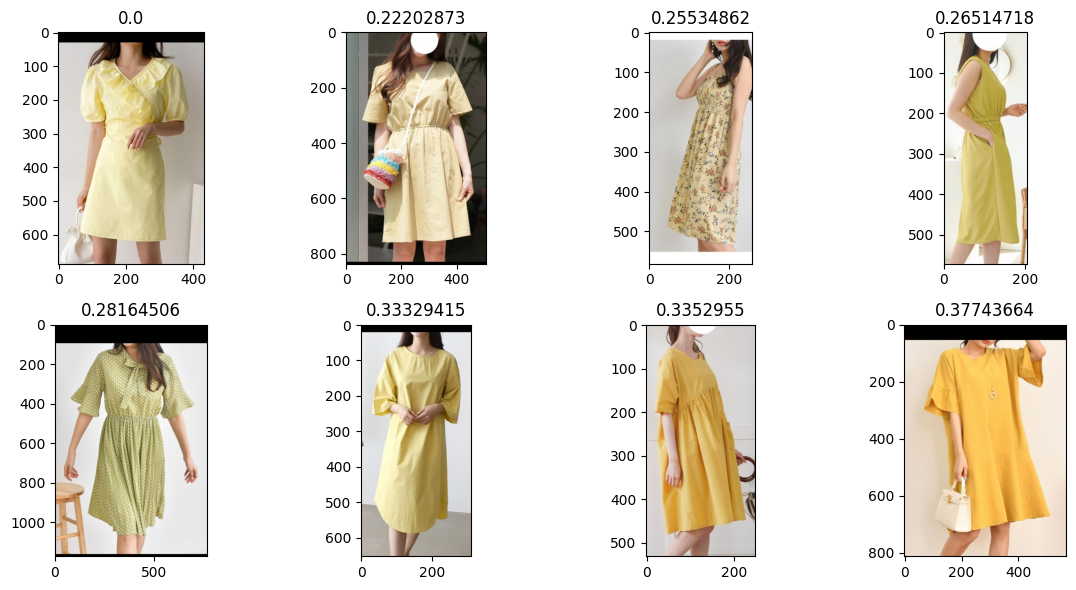

In [27]:
draw_image(image_list, dist_list)

In [28]:
com_feature_list.shape[0]

4352

In [29]:
import numpy as np

d = com_feature_list[0].shape[0]
nlist = int(np.sqrt(com_feature_list.shape[0]))
quantizer = faiss.IndexFlatL2(d)
index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)

index.train(com_feature_list)

index.add(com_feature_list)

assert index.is_trained

faiss.write_index(index, os.path.join(index_dir, 'ivf_index.index'))

k = 8
index.nprobe = 10

random_idx = random.randint(0, len(com_feature_list))
query_vector = com_feature_list[random_idx].reshape(1, -1)

distances, indices = index.search(query_vector, k)

In [30]:
from PIL import Image

margin = 0.1
image_list = []
dist_list = []

for idx, dist in zip(indices[0], distances[0]):
    annot = annotations_dict[image_path_id_list[idx]]
    image_path = annot['image_path']
    image = Image.open(image_path). convert('RGB')
    box = annot['box']

    w = box[2] - box[0]
    h = box[3] - box[1]

    new_box = [
        int(box[0] - w * margin),
        int(box[1] - h * margin),
        int(box[2] + w * margin),
        int(box[3] + h * margin),
    ]
    cropped_image = image.crop(new_box)
    image_list.append(cropped_image)
    dist_list.append(dist)

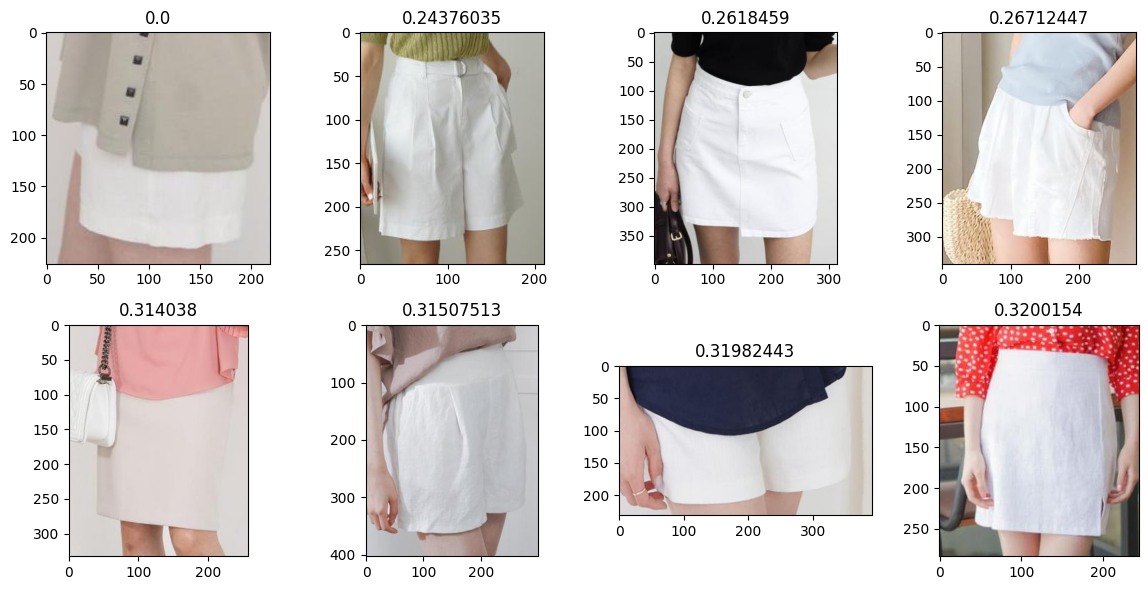

In [31]:
draw_image(image_list, dist_list)

In [35]:
com_feature_list.shape

(4352, 128)

In [36]:
com_feature_list[0].shape[0]

128

In [37]:
com_feature_list.shape[1]

128

In [39]:
d = com_feature_list.shape[1]
M = 32
index = faiss.IndexHNSWFlat(d, M)

index.add(com_feature_list)

faiss.write_index(index, os.path.join(index_dir, 'hnsw_index.index'))

random_idx = random.randint(0, len(com_feature_list))
query_vector = com_feature_list[random_idx].reshape(1, -1)

distances, indices = index.search(query_vector, k)

In [40]:
from PIL import Image

margin = 0.1
image_list = []
dist_list = []

for idx, dist in zip(indices[0], distances[0]):
    annot = annotations_dict[image_path_id_list[idx]]
    image_path = annot['image_path']
    image = Image.open(image_path). convert('RGB')
    box = annot['box']

    w = box[2] - box[0]
    h = box[3] - box[1]

    new_box = [
        int(box[0] - w * margin),
        int(box[1] - h * margin),
        int(box[2] + w * margin),
        int(box[3] + h * margin),
    ]
    cropped_image = image.crop(new_box)
    image_list.append(cropped_image)
    dist_list.append(dist)

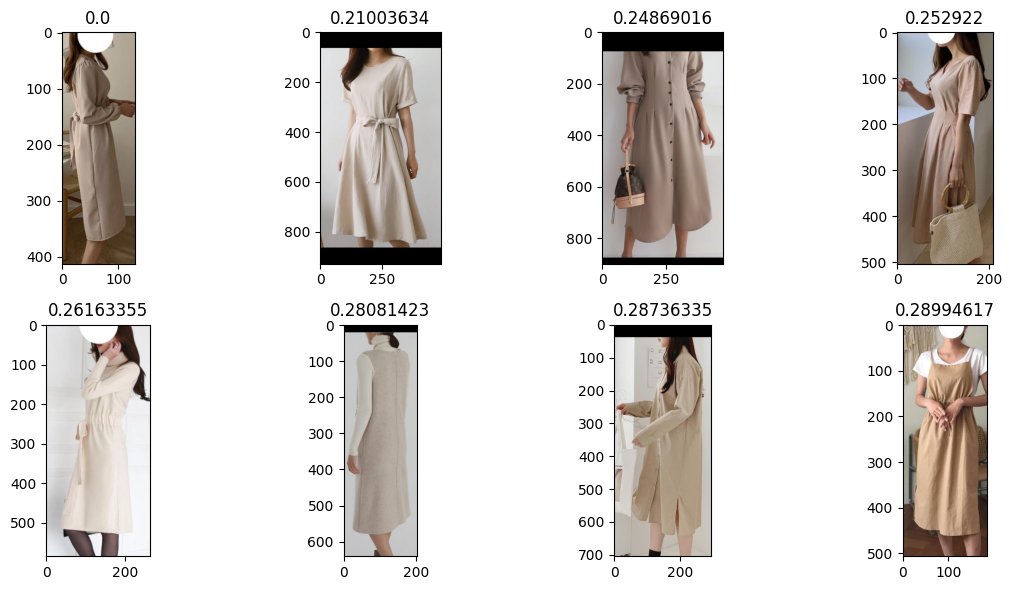

In [41]:
draw_image(image_list, dist_list)